# New Year Sales Analysis
**Objective:** Analyze the New Year sales data to uncover patterns, trends, and customer behavior insights.

## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 2. Load and Explore the Dataset
This raw file contains a couple of non-UTF-8 characters, so we load it with the `latin1` encoding to avoid decode errors.

In [ ]:
df = pd.read_csv('/content/New Year Sales Data.csv', encoding='latin1')
print(df.shape)
df.head()

(11251, 15)


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


## 3. Data Cleaning

###  Check for null values

In [ ]:
df.isnull().sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


### Drop Unnecessary Columns
`Status` and `unnamed1` are completely empty and don't contribute to the analysis.

In [ ]:
df=df.drop(columns=["Status", "unnamed1","Age"],axis=1, errors='ignore')

### Drop rows with null values in other important columns
`Amount` has a small number of nulls — we drop those rows.

In [ ]:
print('Shape before dropping NaNs:', df.shape)
df.dropna(inplace=True)
print('Shape after dropping NaNs:', df.shape)
df.info()

Shape before dropping NaNs: (11251, 12)
Shape after dropping NaNs: (11239, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11239 non-null  int64  
 1   Cust_name         11239 non-null  object 
 2   Product_ID        11239 non-null  object 
 3   Gender            11239 non-null  object 
 4   Age Group         11239 non-null  object 
 5   Marital_Status    11239 non-null  int64  
 6   State             11239 non-null  object 
 7   Zone              11239 non-null  object 
 8   Occupation        11239 non-null  object 
 9   Product_Category  11239 non-null  object 
 10  Orders            11239 non-null  int64  
 11  Amount            11239 non-null  float64
dtypes: float64(1), int64(3), object(8)
memory usage: 1.1+ MB


### Convert the Amount column to an integer type

In [ ]:
df['Amount'] = df['Amount'].astype(int)
df.dtypes

,0
User_ID,int64
Cust_name,object
Product_ID,object
Gender,object
Age Group,object
Marital_Status,int64
State,object
Zone,object
Occupation,object
Product_Category,object


## 4. Data Overview and Summary

### 1. Summary statistics

In [ ]:
df.describe(include='all')

,User_ID,Cust_name,Product_ID,Gender,Age Group,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
count,1.123900e+04,11239,11239,11239,11239,11239.000000,11239,11239,11239,11239,11239.000000,11239.000000
unique,NaN,1250,2350,2,7,NaN,16,5,15,18,NaN,NaN
top,NaN,Vishakha,P00265242,F,26-35,NaN,Uttar Pradesh,Central,IT Sector,Clothing & Apparel,NaN,NaN
freq,NaN,42,53,7832,4541,NaN,1944,4289,1583,2655,NaN,NaN
mean,1.003004e+06,NaN,NaN,NaN,NaN,0.420055,NaN,NaN,NaN,NaN,2.489634,9453.610553
std,1.716039e+03,NaN,NaN,NaN,NaN,0.493589,NaN,NaN,NaN,NaN,1.114967,5222.355168
min,1.000001e+06,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,1.000000,188.000000
25%,1.001492e+06,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,2.000000,5443.000000
50%,1.003064e+06,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,2.000000,8109.000000
75%,1.004426e+06,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,12675.000000


### 2. Unique values in each column

In [ ]:
for col in df.columns:
  print(f"\ncolumn: {col}")
  print(f"Number of unique values: {df[col].nunique()}")
  print(df[col].unique())


column: User_ID
Number of unique values: 3752
[1002903 1000732 1001990 ... 1001542 1004378 1005258]

column: Cust_name
Number of unique values: 1250
['Sanskriti' 'Kartik' 'Bindu' ... 'Chris' 'Madan Mohan' 'Nicole']

column: Product_ID
Number of unique values: 2350
['P00125942' 'P00110942' 'P00118542' ... 'P00307142' 'P00044742'
 'P00296942']

column: Gender
Number of unique values: 2
['F' 'M']

column: Age Group
Number of unique values: 7
['26-35' '0-17' '18-25' '51-55' '46-50' '55+' '36-45']

column: Marital_Status
Number of unique values: 2
[0 1]

column: State
Number of unique values: 16
['Maharashtra' 'Andhra\xa0Pradesh' 'Uttar Pradesh' 'Karnataka' 'Gujarat'
 'Himachal Pradesh' 'Delhi' 'Jharkhand' 'Kerala' 'Haryana'
 'Madhya Pradesh' 'Bihar' 'Rajasthan' 'Uttarakhand' 'Telangana' 'Punjab']

column: Zone
Number of unique values: 5
['Western' 'Southern' 'Central' 'Northern' 'Eastern']

column: Occupation
Number of unique values: 15
['Healthcare' 'Govt' 'Automobile' 'Construction' 'Fo

# Exploratory Data Analysis (EDA)

### 1.Gender Analysis
**Which gender has a higher purchasing power?**

- `count plot` for gender.
- `bar chart` to show the total purchase amount by gender.



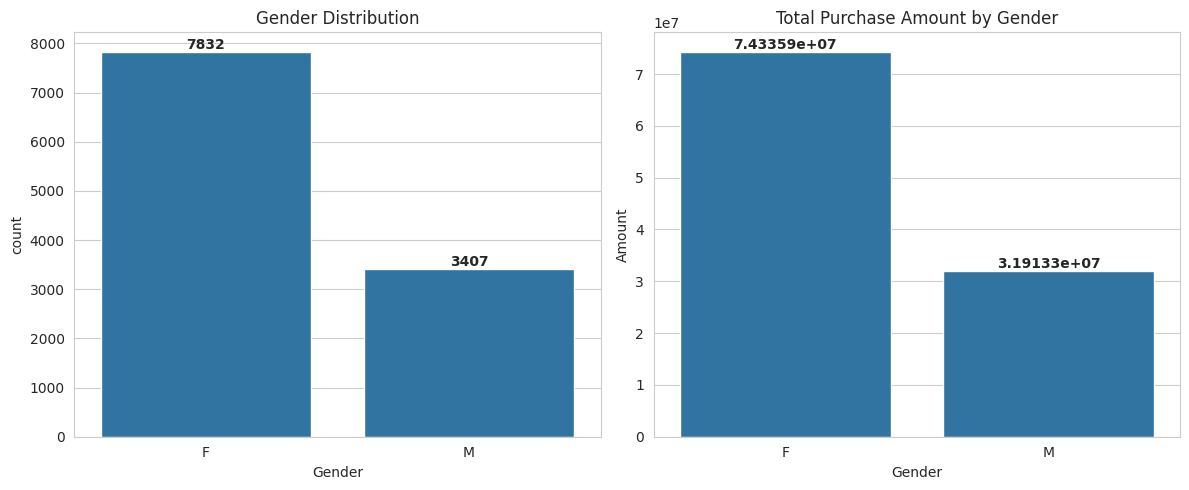

In [ ]:
sns.set_style('whitegrid')
fig, ax=plt.subplots(1,2,figsize=(12,5))
sns.countplot(x='Gender', data=df, ax=ax[0])
ax[0].set_title('Gender Distribution')
for container in ax[0].containers:
    ax[0].bar_label(container, fontweight='bold')

sns.barplot(x='Gender', y='Amount', data=df.groupby('Gender')['Amount'].sum().reset_index(), ax=ax[1])
ax[1].set_title('Total Purchase Amount by Gender')
for container in ax[1].containers:
    ax[1].bar_label(container, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.Age Group Analysis
**Which age group has the most purchases, and is there a trend in purchasing power by age?**

- `count plot` of age groups with hue as gender.
- `bar chart` showing total purchase amount by age group.

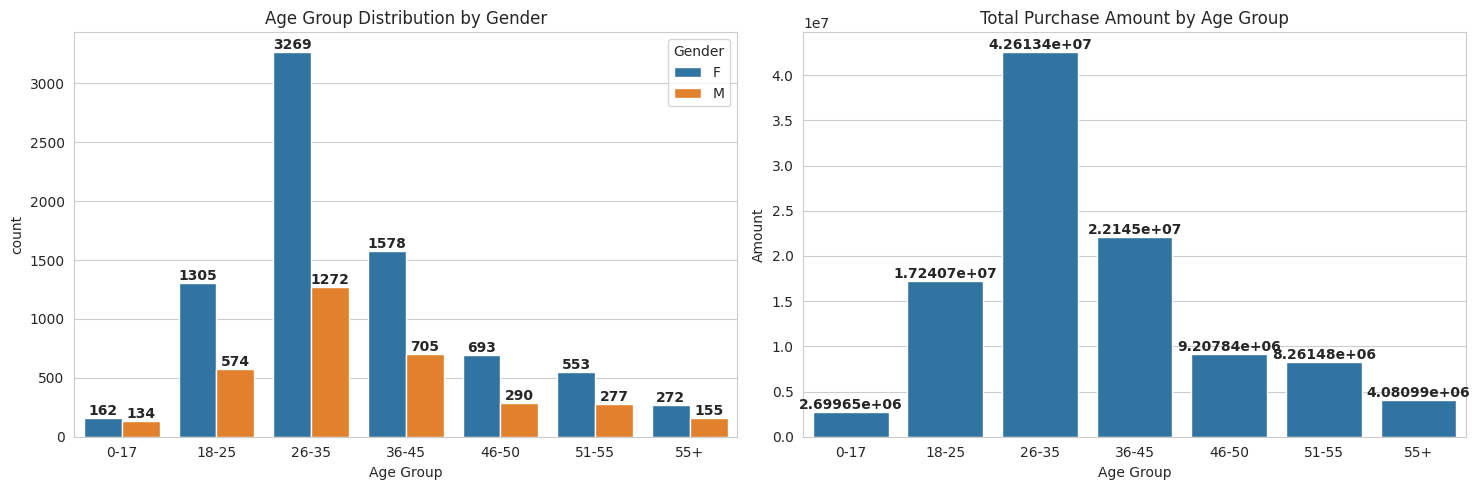

In [ ]:
age_group_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
df['Age Group'] = pd.Categorical(df['Age Group'], categories=age_group_order, ordered=True)


fig, ax=plt.subplots(1,2,figsize=(15,5))
sns.countplot(x='Age Group', hue='Gender', data=df, ax=ax[0])
ax[0].set_title('Age Group Distribution by Gender')
for container in ax[0].containers:
    ax[0].bar_label(container, fontweight='bold')

sns.barplot(x='Age Group', y='Amount', data=df.groupby('Age Group', observed=True)['Amount'].sum().reset_index(), ax=ax[1])
ax[1].set_title('Total Purchase Amount by Age Group')
for container in ax[1].containers:
  ax[1].bar_label(container, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.State Analysis
**Which states generate the highest number of orders and revenue?**
 - `bar charts` for the number of orders and total amount by state, focusing on
the top 10 states.

/tmp/ipykernel_1905/282957594.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
/tmp/ipykernel_1905/282957594.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)


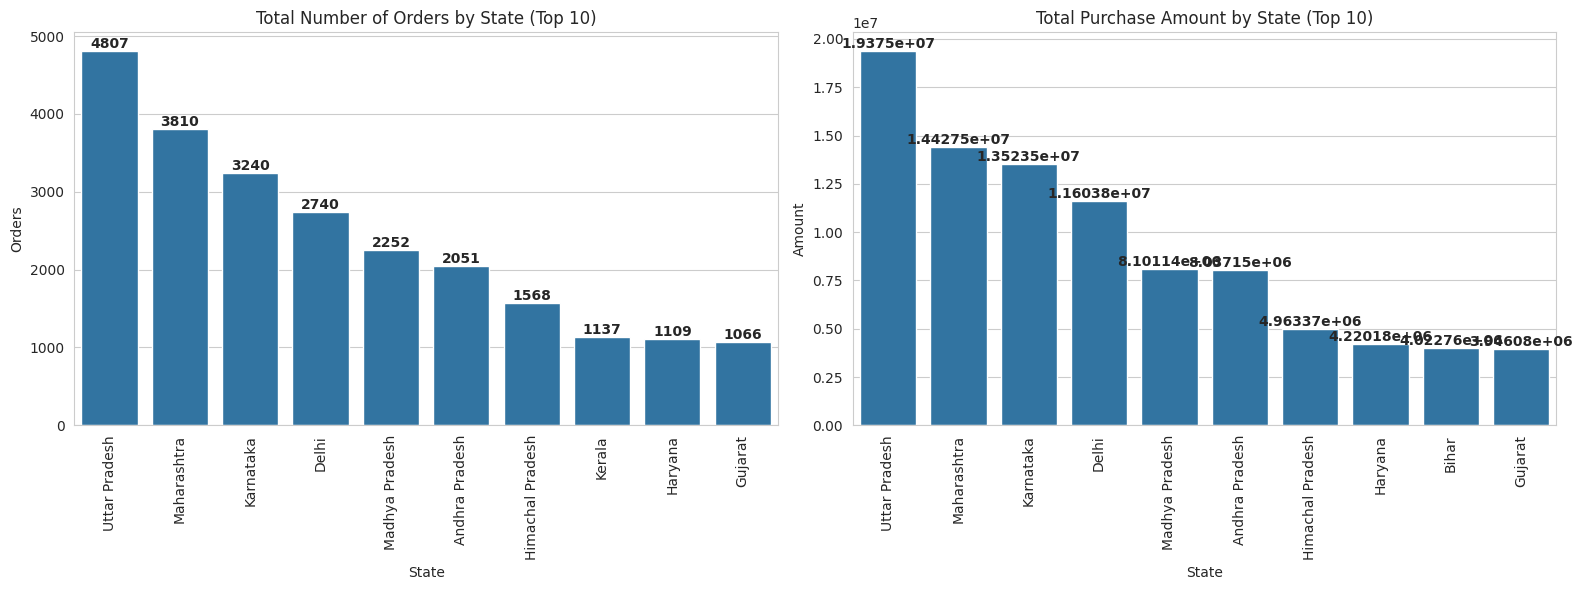

In [ ]:
fig, ax=plt.subplots(1,2,figsize=(16,6))
sns.barplot(x='State', y='Orders', data=df.groupby('State')['Orders'].sum().sort_values(ascending=False).head(10).reset_index(), ax=ax[0])
ax[0].set_title('Total Number of Orders by State (Top 10)')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
for container in ax[0].containers:
    ax[0].bar_label(container, fontweight='bold')

sns.barplot(x='State', y='Amount', data=df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10).reset_index(), ax=ax[1])
ax[1].set_title('Total Purchase Amount by State (Top 10)')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
for container in ax[1].containers:
    ax[1].bar_label(container, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.Marital Status Analysis
**How does marital status affect purchasing behavior?**
 - `count plot` for marital status and a `bar chart` showing total amount spent
by marital status, with gender as a hue.

/tmp/ipykernel_1905/351821221.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Unmarried (0)', 'Married (1)'])
/tmp/ipykernel_1905/351821221.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Unmarried (0)', 'Married (1)'])


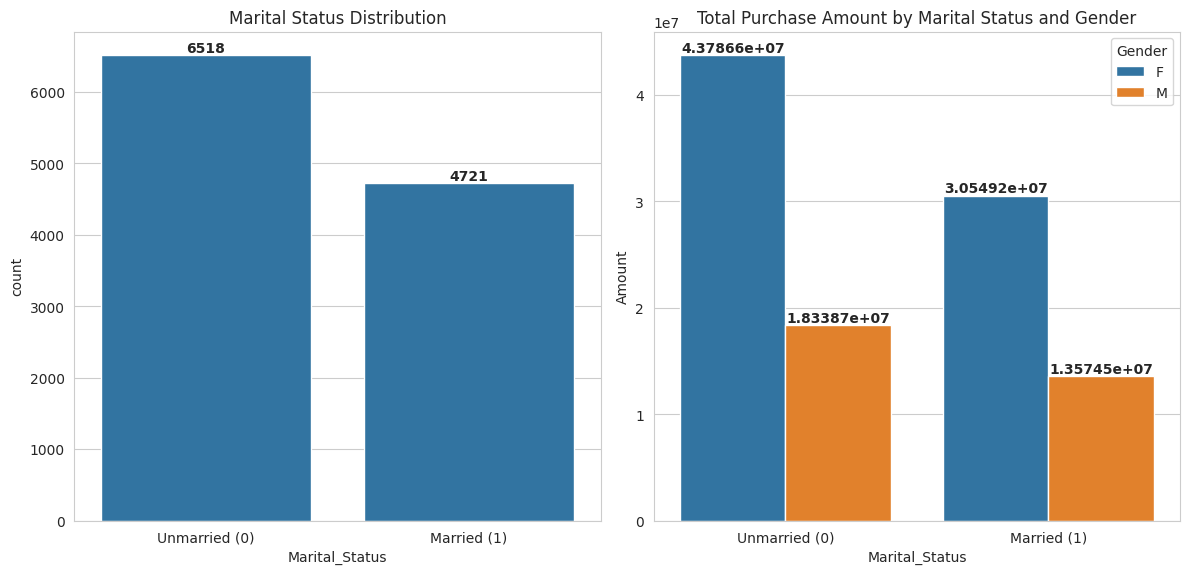

In [ ]:
fig, ax=plt.subplots(1,2,figsize=(12,6))
sns.countplot(x='Marital_Status', data=df, ax=ax[0])
ax[0].set_title('Marital Status Distribution')
ax[0].set_xticklabels(['Unmarried (0)', 'Married (1)'])
for container in ax[0].containers:
    ax[0].bar_label(container, fontweight='bold')

sns.barplot(x='Marital_Status', y='Amount', hue='Gender', data=df.groupby(['Marital_Status', 'Gender'])['Amount'].sum().reset_index(), ax=ax[1])
ax[1].set_title('Total Purchase Amount by Marital Status and Gender')
ax[1].set_xticklabels(['Unmarried (0)', 'Married (1)'])
for container in ax[1].containers:
  ax[1].bar_label(container, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. Occupation Analysis
**Which occupations contribute most to sales?**
 - `count plot` for occupation and a `bar chart` for total sales by occupation.

/tmp/ipykernel_1905/219229928.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
/tmp/ipykernel_1905/219229928.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)


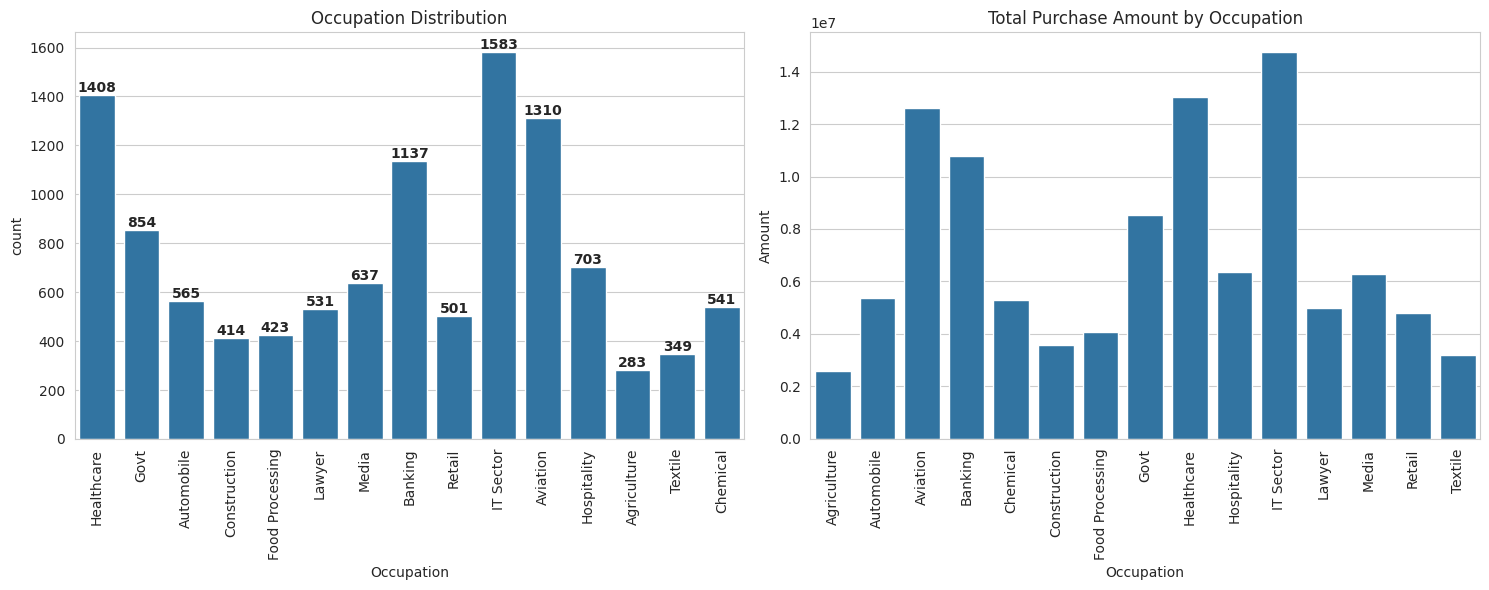

In [ ]:
fig, ax=plt.subplots(1,2,figsize=(15,6))
sns.countplot(x='Occupation', data=df, ax=ax[0])
ax[0].set_title('Occupation Distribution')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
for container in ax[0].containers:
    ax[0].bar_label(container, fontweight='bold')

sns.barplot(x='Occupation', y='Amount', data=df.groupby('Occupation')['Amount'].sum().reset_index(), ax=ax[1])
ax[1].set_title('Total Purchase Amount by Occupation')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()


### 6. Product Category Analysis
**What product categories are the most popular, and which ones generate the
most revenue?**
- `count plot` for product categories.
- `bar chart` to show the total amount by product category for the top
categories.


/tmp/ipykernel_1905/2577222691.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
/tmp/ipykernel_1905/2577222691.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)


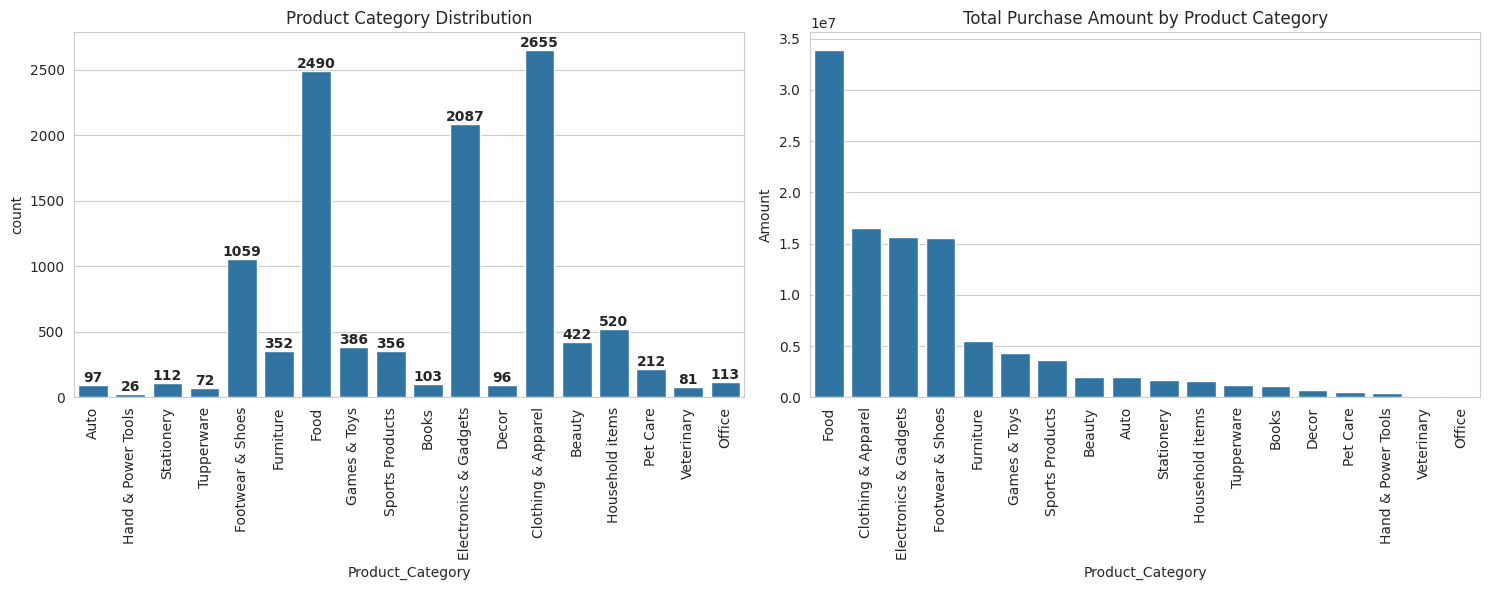

In [ ]:
fig, ax=plt.subplots(1,2,figsize=(15,6))
sns.countplot(x='Product_Category', data=df, ax=ax[0])
ax[0].set_title('Product Category Distribution')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
for container in ax[0].containers:
    ax[0].bar_label(container, fontweight='bold')

sns.barplot(x='Product_Category', y='Amount', data=df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False).reset_index(), ax=ax[1])
ax[1].set_title('Total Purchase Amount by Product Category')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()

# Conclusion

In [ ]:
top_gender_label = df.groupby('Gender', observed=True)['Amount'].sum().idxmax()
top_age_group_label = df.groupby('Age Group', observed=True)['Amount'].sum().idxmax()
top_state_label = df.groupby('State', observed=True)['Amount'].sum().idxmax()

marital_gender_sales = df.groupby(['Marital_Status', 'Gender'], observed=True)['Amount'].sum().reset_index()
top_marital_row = marital_gender_sales.loc[marital_gender_sales['Amount'].idxmax()]
top_marital_status_val = top_marital_row['Marital_Status']
top_marital_gender_val = top_marital_row['Gender']
top_marital_status_str = 'Married' if top_marital_status_val == 1 else 'Unmarried'
top_marital_label = f"{top_marital_status_str} ({top_marital_gender_val})"

top_occupation_label = df.groupby('Occupation', observed=True)['Amount'].sum().idxmax()
top_category_label = df.groupby('Product_Category', observed=True)['Amount'].sum().idxmax()

print("Typical High-Purchasing Customer Profile")
print("-" * 45)
print(f"Gender: {top_gender_label}")
print(f"Age Group: {top_age_group_label}")
print(f"State: {top_state_label}")
print(f"Marital Status: {top_marital_label}")
print(f"Occupation: {top_occupation_label}")
print(f"Preferred Product Category: {top_category_label}")

Typical High-Purchasing Customer Profile
---------------------------------------------
Gender: F
Age Group: 26-35
State: Uttar Pradesh
Marital Status: Unmarried (F)
Occupation: IT Sector
Preferred Product Category: Food


# Additional Questions

### 1. Which age group contributes the most to each product category, and does this vary by gender?

In [ ]:
age_category = df.groupby(['Product_Category', 'Age Group'])['Amount'].sum().unstack()
top_age_per_category = age_category.idxmax(axis=1)
print(top_age_per_category) #which age group contributes more for each product.

age_category_gender = df.groupby(['Product_Category', 'Age Group', 'Gender'])['Amount'].sum().unstack(level='Gender')
age_category_gender.head(15)

Product_Category
Auto                     26-35
Beauty                   26-35
Books                    26-35
Clothing & Apparel       26-35
Decor                    26-35
Electronics & Gadgets    26-35
Food                     26-35
Footwear & Shoes         26-35
Furniture                26-35
Games & Toys             26-35
Hand & Power Tools       26-35
Household items          26-35
Office                   26-35
Pet Care                 26-35
Sports Products          26-35
Stationery               26-35
Tupperware               26-35
Veterinary               26-35
dtype: category
Categories (7, object): ['0-17' < '18-25' < '26-35' < '36-45' < '46-50' < '51-55' < '55+']


/tmp/ipykernel_1905/1537246745.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_category = df.groupby(['Product_Category', 'Age Group'])['Amount'].sum().unstack()
/tmp/ipykernel_1905/1537246745.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_category_gender = df.groupby(['Product_Category', 'Age Group', 'Gender'])['Amount'].sum().unstack(level='Gender')


Gender                           F       M
Product_Category Age Group                
Auto             0-17         9732   47151
                 18-25      288925   61369
                 26-35      541529  353578
                 36-45      263399   61121
                 46-50       61132   18608
                 51-55      107011   65652
                 55+         14063   65339
Beauty           0-17        30429   10700
                 18-25      249280   95107
                 26-35      622801  149580
                 36-45      277227   86931
                 46-50      120981   45332
                 51-55      160796   29362
                 55+         62743   18215
Books            0-17            0   10249

### 2. How does the amount spent vary by marital status across different age groups?


In [ ]:
maritalstatus_age = df.groupby(['Marital_Status', 'Age Group'])['Amount'].sum().unstack()
maritalstatus_age.head(15)

/tmp/ipykernel_1905/862756686.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  maritalstatus_age = df.groupby(['Marital_Status', 'Age Group'])['Amount'].sum().unstack()


Age Group,0-17,18-25,26-35,36-45,46-50,51-55,55+
Marital_Status,,,,,,,
0,1655299,9781617,25008749,12870401,5472555,4884765,2451998
1,1044354,7459115,17604693,9274593,3735289,3376712,1628989


### 3. Which states show the highest growth in orders and revenue?


In [ ]:
states_orders = df.groupby('State')['Orders'].sum().sort_values(ascending=False)
states_revenue = df.groupby('State')['Amount'].sum().sort_values(ascending=False)
print(states_orders.head(10))
print(states_revenue.head(10))

State
Uttar Pradesh       4807
Maharashtra         3810
Karnataka           3240
Delhi               2740
Madhya Pradesh      2252
Andhra Pradesh      2051
Himachal Pradesh    1568
Kerala              1137
Haryana             1109
Gujarat             1066
Name: Orders, dtype: int64
State
Uttar Pradesh       19374968
Maharashtra         14427543
Karnataka           13523540
Delhi               11603818
Madhya Pradesh       8101142
Andhra Pradesh       8037146
Himachal Pradesh     4963368
Haryana              4220175
Bihar                4022757
Gujarat              3946082
Name: Amount, dtype: int64


### 4. Are there specific occupations that prefer particular product categories more than others?

In [ ]:
occ_prod_cat = df.groupby(['Occupation', 'Product_Category'])['Amount'].sum().unstack()
top_cat_per_occ = occ_prod_cat.idxmax(axis=1)
print(top_cat_per_occ)

Occupation
Agriculture        Food
Automobile         Food
Aviation           Food
Banking            Food
Chemical           Food
Construction       Food
Food Processing    Food
Govt               Food
Healthcare         Food
Hospitality        Food
IT Sector          Food
Lawyer             Food
Media              Food
Retail             Food
Textile            Food
dtype: object


### 5. What is the correlation between age group and spending amount, and does this differ by gender?

In [ ]:
overall_corr = df['Age Group'].cat.codes.corr(df['Amount'])
print(f"correlation between age group and amount: {overall_corr}")

female_df = df[df['Gender'] == 'F']
male_df = df[df['Gender'] == 'M']

corr_female = female_df['Age Group'].cat.codes.corr(female_df['Amount'])
corr_male = male_df['Age Group'].cat.codes.corr(male_df['Amount'])

print(f"correlation between age Group and amount for Female customers: {corr_female}")
print(f"correlation between age Group and amount for Male customers: {corr_male}")

correlation between age group and amount: 0.03204769766106408
correlation between age Group and amount for Female customers: 0.02354044946653379
correlation between age Group and amount for Male customers: 0.05030961266193619
